# Exploratory Data Analysis - IPL Auction Price Project


## Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats


In [ ]:

DATA_PATH = r"/content/final_modelling_ready_dataset.csv"
OUTPUT_DIR = r"/content/images"

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.size"] = 11

In [ ]:
def save(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print("saved figure:", filename)

## Load the data

In [ ]:
data = pd.read_csv(DATA_PATH)
df = data.copy()
print("Full dataset shape:", df.shape)
print(df.info())

df["log_price"] = np.where((df["auction_result"] == "sold")
            & df["sold_price"].notna() & (df["sold_price"] > 0), np.log(df["sold_price"]), np.nan)



have_usd = df['sold_price_in_usd'].notna()
have_inr = df['sold_price'].notna() & (df['sold_price'] > 0)
print("Years with USD :", df.loc[have_usd, "year"].unique())
print("Years no USD   :", sorted(set(df["year"].unique()) - set(df.loc[have_usd, "year"].unique())))
print("Years with INR :", df.loc[have_inr, "year"].unique())
print("Years no INR   :", sorted(set(df["year"].unique()) - set(df.loc[have_inr, "year"].unique())))

neither = df[~have_usd & ~have_inr]
print("Neither:", len(neither))
print(neither["auction_result"].value_counts(dropna=False))

priced = df[(df["auction_result"] == "sold")
            & df["sold_price"].notna() & (df["sold_price"] > 0)].copy()

priced['sold_price_cr'] = priced['sold_price']/10000000
total_players = df[df["auction_result"].isin(["sold", "retained", "transferred","unsold",])].copy()

auctioned = df[df["auction_result"].isin(["sold", "unsold"])].copy()
auctioned['sold_price_cr'] = df['sold_price']/10000000


print("Priced rows   :", len(priced))
print("Auctioned rows:", len(auctioned))
print("Totar players:", len(total_players))



Full dataset shape: (4028, 68)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4028 entries, 0 to 4027
Data columns (total 68 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  4028 non-null   int64  
 1   player_id             4011 non-null   float64
 2   player_name           4028 non-null   object 
 3   team                  2822 non-null   object 
 4   sold_price            2792 non-null   float64
 5   sold_price_in_cr      2792 non-null   float64
 6   sold_price_in_usd     2153 non-null   float64
 7   base_price            2299 non-null   float64
 8   base_price_in_cr      2299 non-null   float64
 9   base_price_in_usd     211 non-null    float64
 10  purse_spent           2348 non-null   float64
 11  purse_spent_in_cr     2348 non-null   float64
 12  purse_left            2348 non-null   float64
 13  purse_left_in_cr      2348 non-null   float64
 14  status                2527 non-null   obj

"In the modeling dataset, the priced rows shows 1644 players who went into the auction and have price.\nThere are players who don't have sold price that is 1236, out of which 1198 are the players who remain\nunsold during the auction and NaN shows that these are the players whose sold price is not mentioned or\nnot there on the official page of ESPN website and 6 are the players who has been transferred, so there\nsold price is also not disclosed as it remains confidetial between the teams.  Auctioned rows shows\nthat this many total players have a result like sold, unsold are 2842 and. Total_players are the players which have auction_result like sold,unsold,retained and transferred"

In [ ]:
print(data.shape)

(4028, 68)


## SECTION 1 - PRICE DISTRIBUTION  (justifies the log transform)

In [ ]:

price_summary = priced['sold_price_cr'].describe()
price_summary['median'] = priced['sold_price_cr'].median()
price_summary['skew_raw'] = priced['sold_price'].skew()
price_summary['skew_log'] = priced['log_price'].skew()
price_summary.to_csv(os.path.join(OUTPUT_DIR, "01_price_summary.csv"))
print(price_summary.round(3))


count       1644.000
mean           2.331
std            3.269
min            0.091
25%            0.300
50%            1.000
75%            3.000
max           27.000
median         1.000
skew_raw       2.873
skew_log       0.056
Name: sold_price_cr, dtype: float64


In [ ]:

top50_players = priced.sort_values("sold_price_cr", ascending=False).head(50)
top50_players_table = top50_players[["year","player_name", "team" ,"sold_price_cr", "player_role"]]
top50_players_table.to_csv(os.path.join(OUTPUT_DIR, "01_top10_expensive_players.csv"), index=False)
print("\nTop 50 most expensive buys:")
print(top50_players_table.to_string(index=False))


Top 50 most expensive buys:
 year      player_name                        team  sold_price_cr         player_role
 2025          RR Pant        Lucknow Super Giants          27.00 Wicketkeeper Batter
 2025          SS Iyer                Punjab Kings          26.75    Top order Batter
 2026          C Green       Kolkata Knight Riders          25.20  Batting Allrounder
 2024   Mitchell Starc       Kolkata Knight Riders          24.75              Bowler
 2025          VR Iyer       Kolkata Knight Riders          23.75          Allrounder
 2024      Pat Cummins         Sunrisers Hyderabad          20.50              Bowler
 2023       Sam Curran                Punjab Kings          18.50          Allrounder
 2025        YS Chahal                Punjab Kings          18.00              Bowler
 2025   Arshdeep Singh                Punjab Kings          18.00              Bowler
 2026      M Pathirana       Kolkata Knight Riders          18.00              Bowler
 2023    Cameron Green   

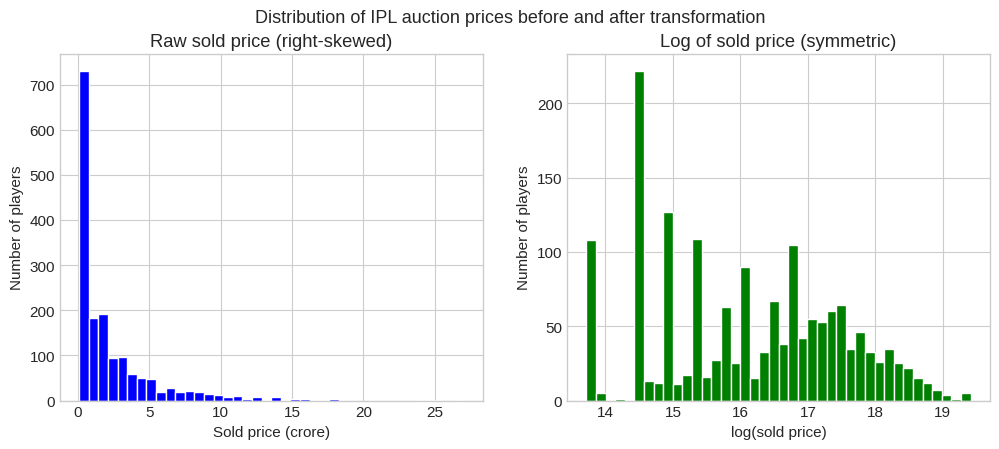

saved figure: 01_price_distribution.png


'This is the proof, that the raw sold price is heavily right skewed and on doing log-transformation it makes symmetric. '

In [ ]:

figure,axes = plt.subplots(1,2,figsize=(12,4.5))
axes[0].hist(priced['sold_price_cr'].dropna(), bins=40, color="blue", edgecolor="white")
axes[0].set_title("Raw sold price (right-skewed)")
axes[0].set_xlabel("Sold price (crore)")
axes[0].set_ylabel("Number of players")

axes[1].hist(priced['log_price'].dropna(), bins=40, color="green", edgecolor="white")
axes[1].set_title("Log of sold price (symmetric)")
axes[1].set_xlabel("log(sold price)")
axes[1].set_ylabel("Number of players")

figure.suptitle("Distribution of IPL auction prices before and after transformation", fontsize=13)
save(figure, "01_price_distribution.png")


year
2008     75
2009     17
2010     11
2011    127
2012     25
2013     37
2014    154
2015     67
2016     94
2017     66
2018    169
2019     67
2020     63
2021     57
2022    204
2023     80
2024     72
2025    182
2026     77
dtype: int64


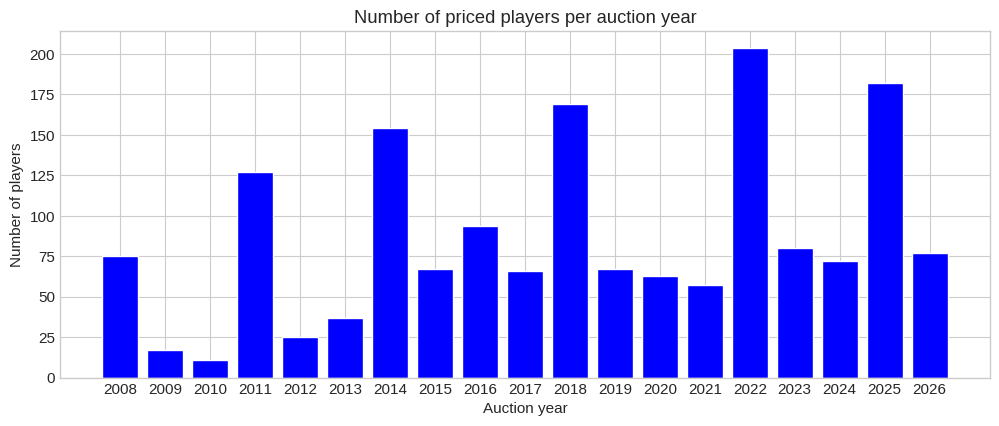

saved figure: 02_players_count_per_year.png


'It can be noticed that during the mega auction years like 2008/11/14/18/22/25 have high number of players purchased\nby team, whereas during mini auction '

In [ ]:

players_count_per_year = priced.groupby("year").size()
print(players_count_per_year)
players_count_per_year.to_csv(os.path.join(OUTPUT_DIR, "players_count_per_year.csv"))
figure, axes = plt.subplots(figsize=(12, 4.5))
axes.bar(players_count_per_year.index, players_count_per_year.values,color='blue',edgecolor="white")
axes.set_title("Number of priced players per auction year")
axes.set_xlabel("Auction year")
axes.set_ylabel("Number of players")
axes.set_xticks(players_count_per_year.index)
save(figure, "02_players_count_per_year.png")



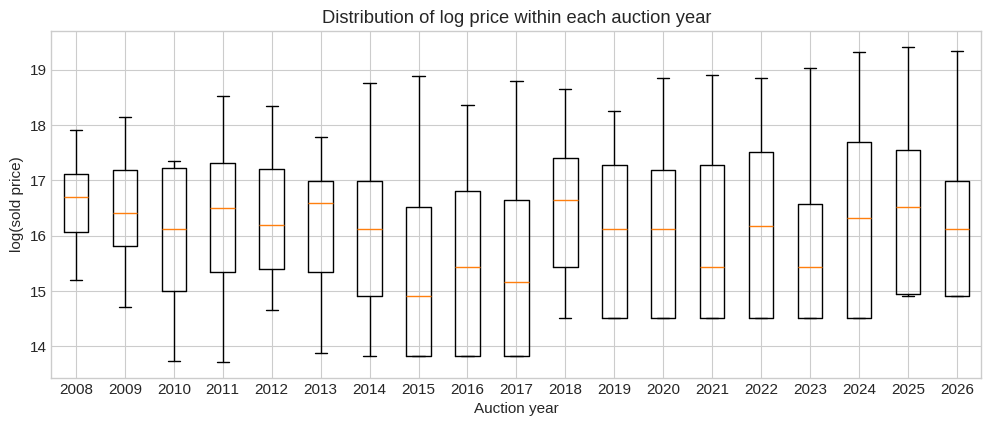

saved figure: logprice_boxplot_year_wise.png


In [ ]:

sorted_years = sorted(priced['year'].unique())

data_year_wise = []
for year in sorted_years:
  values = priced.loc[priced['year']==year, 'log_price'].dropna().values
  data_year_wise.append(values)

figure,axes = plt.subplots(figsize=(12,4.5))
axes.boxplot(data_year_wise)
axes.set_xticklabels(sorted_years)
axes.set_title("Distribution of log price within each auction year")
axes.set_xlabel("Auction year")
axes.set_ylabel("log(sold price)")
save(figure, "logprice_boxplot_year_wise.png")

                count  percent
auction_result                
sold             1644     41.1
unsold           1198     30.0
retained         1108     27.7
transferred        46      1.2
                count  median  mean
auction_result                     
retained         1108     3.0  4.70
sold             1644     1.0  2.33
transferred        40     3.1  5.90


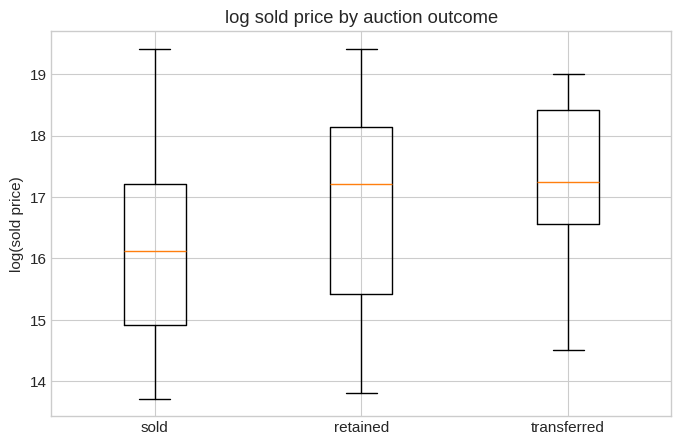

saved figure: log_sold_price_by_auction_outcome.png
                          count  percent
is_capped auction_result                
False     unsold            699     42.1
          sold              643     38.7
          retained          311     18.7
          transferred         9      0.5
True      sold             1001     42.9
          retained          797     34.1
          unsold            499     21.4
          transferred        37      1.6


'From the data I found that out of total, 41.1 percent players has been sold which constitute for 1644, 30% remain\nunsold which constitute for 1198, around 28% of players are been retained who number is 1108, and only 46 players are\nbeen\ntransferred from one team to another that is only 1.2%.\nAs expected the retained and transferred players have high mean and median, whereas sold players have lowest mean.\nEven there is a hug difference in the number of players who was capped and sold or retained and who was uncapped and get\nsold or retained. Also, it is as expected that the players who was uncapped will high number of unsold players as compared\nto players who is capped '

In [ ]:

counts = df['auction_result'].value_counts()
percentage = (df['auction_result'].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({"count": counts, "percent": percentage}))


priced_any = df[df["sold_price"].notna() & (df["sold_price"] > 0)]
print(priced_any.groupby("auction_result")["sold_price_in_cr"].agg(["count", "median", "mean"]).round(2))


order = ["sold", "retained", "transferred"]
datas = []
labels = []

for outcome in order:
  log_values = np.log(priced_any.loc[priced_any["auction_result"] == outcome, "sold_price"]).dropna().values
  if len(log_values)>0:
    datas.append(log_values)
    labels.append(outcome)
figure, axes = plt.subplots(figsize=(8, 5))
axes.boxplot(datas)
axes.set_xticks(range(1, len(labels) + 1))
axes.set_xticklabels(labels)
axes.set_title("log sold price by auction outcome")
axes.set_ylabel("log(sold price)")
figure.suptitle("", fontsize=13)
save(figure, "log_sold_price_by_auction_outcome.png")



capped_counts = df.groupby("is_capped")["auction_result"].value_counts()
capped_percentage = (df.groupby("is_capped")["auction_result"].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({"count": capped_counts, "percent": capped_percentage}))




auction_result  retained  sold  transferred  unsold
year                                               
2008                   0    75            0       2
2009                   0    17            0       0
2010                   0    11            0       0
2011                  12   127            0       0
2012                   3    25            6      44
2013                   0    37            0      37
2014                   0   154            0       0
2015                   0    67            0     147
2016                   0    94            0     131
2017                 139    66            0      93
2018                  18   169            0     126
2019                 123    67            0      80
2020                 117    63            9      63
2021                 136    57            3      72
2022                  27   204            6      92
2023                 158    80            5      70
2024                 166    72            7      60
2025        

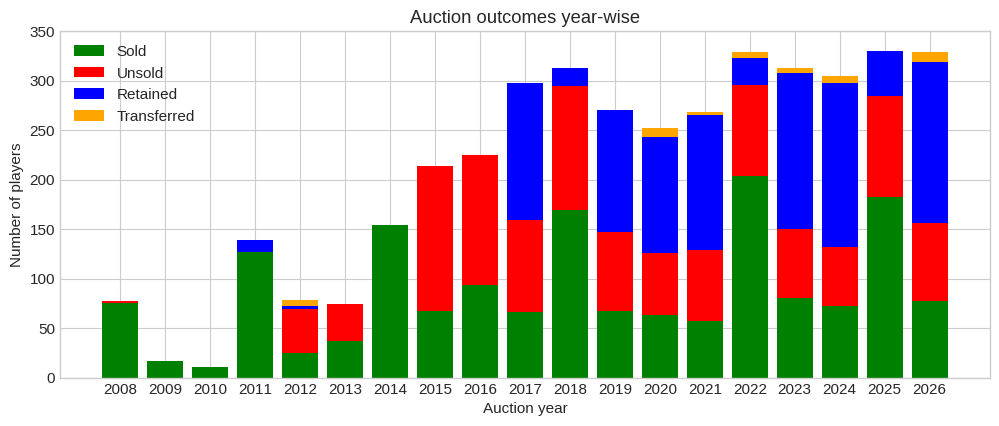

saved figure: auction_outcome_year_wise.png


'It has been observed that from 2017 we have data of players who has been retained or transferred, we can see\nthat during the mini auctions like 2017/19/20/21/23/24/26 have highest number of players been retained which is as\nexpected. Also during mega auction many players went into the auction and get sold there we can see totally opposite\nscenario as compared to mini auction. '

In [ ]:

auction_outcome_by_year = total_players.groupby("year")["auction_result"].value_counts().unstack(fill_value=0)
auction_outcome_by_year.to_csv(os.path.join(OUTPUT_DIR, "auction_outcome_by_year.csv"))
print(auction_outcome_by_year)
figure,axes = plt.subplots(figsize=(12,4.5))
axes.bar(auction_outcome_by_year.index, auction_outcome_by_year["sold"], label="Sold", color="green")
axes.bar(auction_outcome_by_year.index,auction_outcome_by_year['unsold'],
         bottom = auction_outcome_by_year['sold']  ,label='Unsold',color='red')
axes.bar(auction_outcome_by_year.index,auction_outcome_by_year['retained'],
         bottom = auction_outcome_by_year['sold'] + auction_outcome_by_year['unsold'] ,label='Retained',
         color='blue')
axes.bar(auction_outcome_by_year.index,auction_outcome_by_year['transferred'],
         bottom = auction_outcome_by_year['sold'] + auction_outcome_by_year['unsold'] + auction_outcome_by_year['retained'] ,
         label='Transferred',
         color='orange')
axes.set_title("Auction outcomes year-wise")
axes.set_xlabel("Auction year")
axes.set_ylabel("Number of players")
axes.set_ylim(0,350)
axes.set_xticks(auction_outcome_by_year.index)
axes.legend()
save(figure, "auction_outcome_year_wise.png")



## SEASON DIMENSION  (price level by auction year)

In [ ]:

compare_cols = ["age_during_auction", "base_price_in_cr", "matches", "runs", "batting_strikerate", "wickets"]
group_means = auctioned.groupby("auction_result")[compare_cols].mean()
group_means.to_csv(os.path.join(OUTPUT_DIR, "03_sold_vs_unsold_means.csv"))
print(" mean characteristics, sold vs unsold ---")
print(group_means.round(2))


 mean characteristics, sold vs unsold ---
                age_during_auction  base_price_in_cr  matches    runs  \
auction_result                                                          
sold                         28.09              0.75     7.87  102.39   
unsold                       29.43              0.43     4.50   48.56   

                batting_strikerate  wickets  
auction_result                               
sold                        106.82     5.86  
unsold                      101.76     2.93  


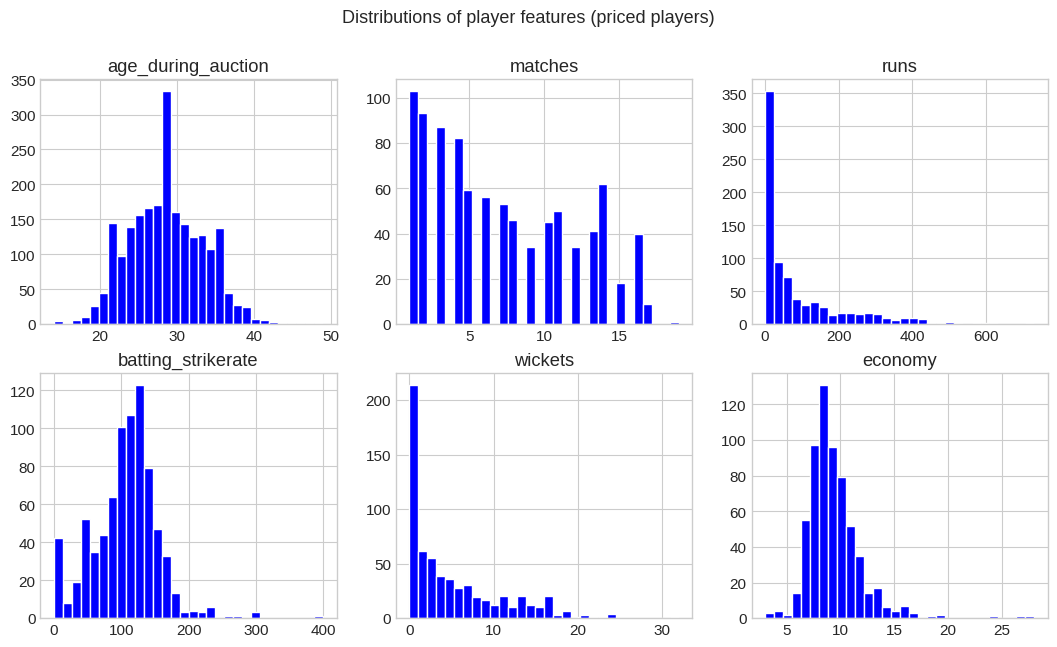

saved figure: feature_distribution.png


In [ ]:

feature_columns = ["age_during_auction", "matches", "runs", "batting_strikerate", "wickets", "economy"]
figure,axes = plt.subplots(2,3,figsize=(13,7))
axes = axes.flatten()
for i in range(len(feature_columns)):
  col = feature_columns[i]
  values = auctioned[col].dropna()
  axes[i].hist(values, bins=30, color="blue", edgecolor="white")
  axes[i].set_title(col,)
figure.suptitle("Distributions of player features (priced players)", fontsize=13)
save(figure, "feature_distribution.png")

In [ ]:
playing_role_map1 = {'Bowling Allrounder':'Allrounder',
                    'Batting Allrounder': 'Allrounder',
                    'Allrounder':'Allrounder',
                    'Bowler':'Bowler',
                    'Top order Batter':'Batsman',
                    'Middle order Batter':'Batsman',
                    'Opening Batter':'Batsman',
                    'Batter':'Batsman',
                    'Wicketkeeper Batter':'Wicketkeeper',
                    'Wicketkeeper':'Wicketkeeper'}

playing_role_map2 = {'Bowling Allrounder':'Allrounder',
                    'Batting Allrounder': 'Allrounder',
                    'Allrounder':'Allrounder',
                    'Bowler':'Bowler',
                    'Top order Batter':'Batsman',
                    'Middle order Batter':'Batsman',
                    'Opening Batter':'Batsman',
                    'Batter':'Batsman',
                    'Wicketkeeper Batter':'Batsman',
                    'Wicketkeeper':'Wicketkeeper'}

playing_role_map3 = {'Bowling Allrounder':'Bowler',
                    'Batting Allrounder': 'Batsman',
                    'Allrounder':'Allrounder',
                    'Bowler':'Bowler',
                    'Top order Batter':'Batsman',
                    'Middle order Batter':'Batsman',
                    'Opening Batter':'Batsman',
                    'Batter':'Batsman',
                    'Wicketkeeper Batter':'Wicketkeeper',
                    'Wicketkeeper':'Wicketkeeper'}

playing_role_map4 = {'Bowling Allrounder':'Bowler',
                    'Batting Allrounder': 'Batsman',
                    'Allrounder':'Allrounder',
                    'Bowler':'Bowler',
                    'Top order Batter':'Batsman',
                    'Middle order Batter':'Batsman',
                    'Opening Batter':'Batsman',
                    'Batter':'Batsman',
                    'Wicketkeeper Batter':'Batsman',
                    'Wicketkeeper':'Wicketkeeper'}


In [ ]:




for name, mapping in [("playing_role_map1",playing_role_map1),
 ("playing_role_map2",playing_role_map2),
  ("playing_role_map3",playing_role_map3),
   ("playing_role_map4",playing_role_map4)]:
   new_df = priced.copy()
   new_df['mapped_playing_role'] = new_df['player_role'].map(mapping)
   print(new_df.groupby("mapped_playing_role").size())
   new_df = new_df.dropna(subset=['mapped_playing_role','log_price'])
   groups = []
   for role,value in new_df.groupby("mapped_playing_role"):
    groups.append(value['log_price'].values)
  #  print(groups)
   f_statistic, p_value = stats.f_oneway(*groups)

   total_mean = new_df['log_price'].mean()
   total_sum_of_squares = ((new_df['log_price'] - total_mean) ** 2).sum()
   sum_of_squares_between_groups = 0
   for g in groups:
    sum_of_squares_between_groups+= (np.mean(g) - total_mean) ** 2 * len(g)
   eta2 = sum_of_squares_between_groups / total_sum_of_squares

   print(name, "| F =", round(f_statistic, 2), "| p =", format(p_value,".1e"), "| eta^2 =", round(eta2, 4))

"""Using ANOVE I have decided that I will go with the playing_role_map1 mapping.
From cricket pov Player role was consolidated into four groups — Batsman, Bowler, Allrounder, and Wicketkeeper — on cricketing and statistical grounds.
Batting-order labels (opening, top-, middle-order) describe lineup position rather than a distinct market role, since franchises buy a batsman and assign an order,
so these were merged. All allrounder subtypes were kept together: in T20 cricket, allrounders are valued for the squad flexibility of
filling both a batting and a bowling slot — easing the four-overseas and impact-player constraints — and command a premium over pure specialists;
assigning them to a specialist pool by their stronger discipline would misattribute this premium and contaminate those pools with dual-skill players.
Wicketkeeper-batsmen and pure keepers were combined, as wicketkeeping is a specialist role every side must fill, and treating keeper-batsmen as ordinary
batsmen would erase the keeping dimension while leaving pure keepers as a negligible category. A one-way ANOVA of log auction price across the four groups
confirmed the grouping is meaningful (F=3.58, p=0.0135);"""


mapped_playing_role
Allrounder      416
Batsman         316
Bowler          592
Wicketkeeper    147
dtype: int64
playing_role_map1 | F = 3.58 | p = 1.3e-02 | eta^2 = 0.0073
mapped_playing_role
Allrounder      416
Batsman         452
Bowler          592
Wicketkeeper     11
dtype: int64
playing_role_map2 | F = 6.17 | p = 3.6e-04 | eta^2 = 0.0125
mapped_playing_role
Allrounder      236
Batsman         390
Bowler          698
Wicketkeeper    147
dtype: int64
playing_role_map3 | F = 1.05 | p = 3.7e-01 | eta^2 = 0.0021
mapped_playing_role
Allrounder      236
Batsman         526
Bowler          698
Wicketkeeper     11
dtype: int64
playing_role_map4 | F = 3.91 | p = 8.6e-03 | eta^2 = 0.0079


'Using ANOVE I have decided that I will go with the playing_role_map1 mapping.\nFrom cricket pov Player role was consolidated into four groups — Batsman, Bowler, Allrounder, and Wicketkeeper — on cricketing and statistical grounds.\nBatting-order labels (opening, top-, middle-order) describe lineup position rather than a distinct market role, since franchises buy a batsman and assign an order,\nso these were merged. All allrounder subtypes were kept together: in T20 cricket, allrounders are valued for the squad flexibility of\nfilling both a batting and a bowling slot — easing the four-overseas and impact-player constraints — and command a premium over pure specialists;\nassigning them to a specialist pool by their stronger discipline would misattribute this premium and contaminate those pools with dual-skill players.\nWicketkeeper-batsmen and pure keepers were combined, as wicketkeeping is a specialist role every side must fill, and treating keeper-batsmen as ordinary\nbatsmen would e

In [ ]:

playing_role_map1 = {'Bowling Allrounder':'Allrounder',
                    'Batting Allrounder': 'Allrounder',
                    'Allrounder':'Allrounder',
                    'Bowler':'Bowler',
                    'Top order Batter':'Batsman',
                    'Middle order Batter':'Batsman',
                    'Opening Batter':'Batsman',
                    'Batter':'Batsman',
                    'Wicketkeeper Batter':'Wicketkeeper',
                    'Wicketkeeper':'Wicketkeeper'}
feature_columns2 = ["age_during_auction", "matches", "runs", "batting_strikerate", "wickets", "economy","log_price","sold_price_cr"]
auctioned['mapped_playing_role'] = auctioned['player_role'].map(playing_role_map1)
role_stats = auctioned.groupby(["auction_result","mapped_playing_role"])[feature_columns2].mean()
role_stats["n_players"] = auctioned.groupby(["auction_result","mapped_playing_role"]).size()

print(role_stats.round(2))

                                    age_during_auction  matches    runs  \
auction_result mapped_playing_role                                        
sold           Allrounder                        28.38     8.02   96.08   
               Batsman                           28.50     8.89  191.22   
               Bowler                            27.79     6.91   15.87   
               Wicketkeeper                      27.69     8.97  183.35   
unsold         Allrounder                        29.79     5.06   47.61   
               Batsman                           29.61     5.16   91.14   
               Bowler                            28.93     3.84    7.47   
               Wicketkeeper                      30.12     4.38   80.44   

                                    batting_strikerate  wickets  economy  \
auction_result mapped_playing_role                                         
sold           Allrounder                       117.10     5.25     9.04   
               Batsma

mapped_playing_role
Bowler          592
Allrounder      416
Batsman         316
Wicketkeeper    147
Name: count, dtype: int64
is_capped
True     1001
False     643
Name: count, dtype: int64


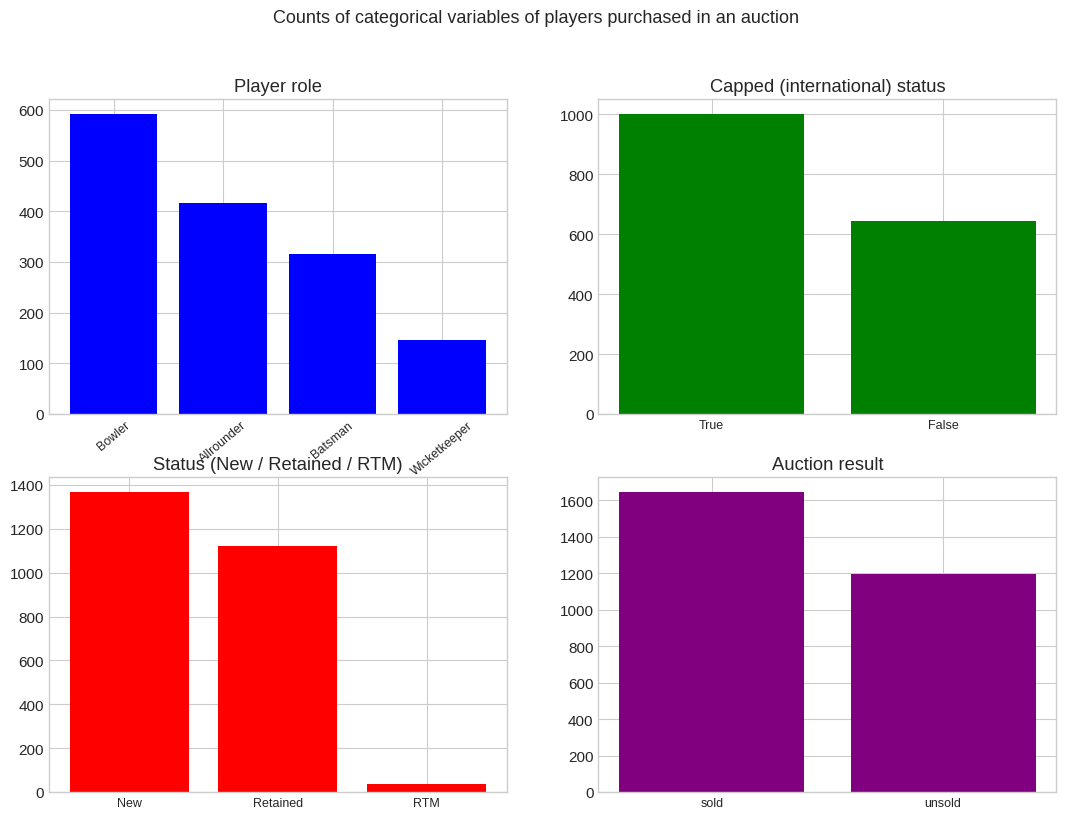

saved figure: 04_categorical_counts.png


'Interesting thing to notice that, initially it was thought that the IPL is used to a batsman game or allrounders game where this are the players got purchased a lot by any team.\nHowever the data shows something else, Bowler is the one who got purchased by many team. But if we see from price perspective then the allrounders are the one who got the highest bidding price,\nfollowed by batsman, wicketkeeper and then bowler.'

In [ ]:
figure, axes = plt.subplots(2,2, figsize=(13, 9))


priced['mapped_playing_role'] = priced['player_role'].map(playing_role_map1)
role_counts = priced["mapped_playing_role"].value_counts()
print(role_counts)
axes[0,0].bar(role_counts.index, role_counts.values, color="blue")

axes[0,0].set_title("Player role")
axes[0,0].tick_params(axis="x", rotation=40)


capped_counts = priced["is_capped"].value_counts()
print(capped_counts)
axes[0,1].bar(capped_counts.index.astype(str), capped_counts.values, color="green")

axes[0,1].set_title("Capped (international) status")


status_counts = df["status"].value_counts()
axes[1, 0].bar(status_counts.index.astype(str), status_counts.values, color="red")
axes[1, 0].set_title("Status (New / Retained / RTM)")


result_counts = auctioned["auction_result"].value_counts()
axes[1,1].bar(result_counts.index.astype(str), result_counts.values, color="purple")

axes[1,1].set_title("Auction result")

figure.suptitle("Counts of categorical variables of players purchased in an auction", fontsize=13)
for ax in axes.flatten():
    ax.tick_params(axis="x", labelsize=9)
save(figure, "04_categorical_counts.png")



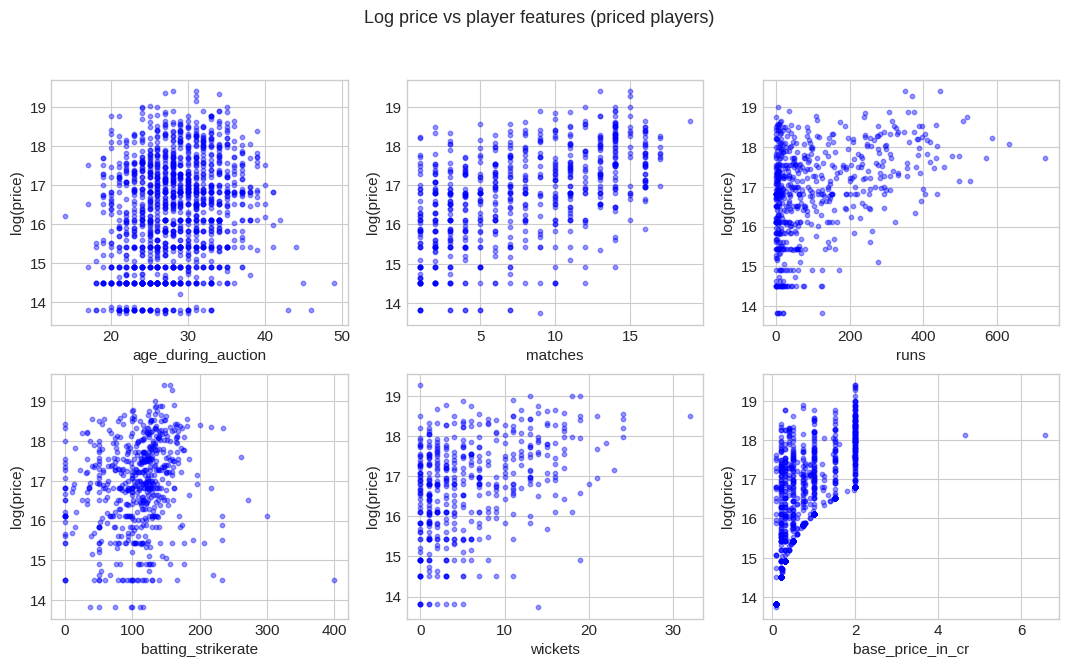

saved figure: log_price_vs_features.png


'From here and using heatmap I can take it out some the numeric variables which shows a direct connection with the log_price like age_during_auction,matches shows an\nexperiece, runs which is very useful for a batsman or batter, strikerate and wickets all of them are showing a clear sign that log-price is increasing with them'

In [ ]:

scatter_cols = ["age_during_auction", "matches", "runs", "batting_strikerate", "wickets", "base_price_in_cr"]
figure, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for i in range(len(scatter_cols)):
    col = scatter_cols[i]
    sub = priced[[col, "log_price"]].dropna()
    axes[i].scatter(sub[col], sub["log_price"], s=10, alpha=0.4, color="blue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("log(price)")
figure.suptitle("Log price vs player features (priced players)", fontsize=13)
save(figure, "log_price_vs_features.png")



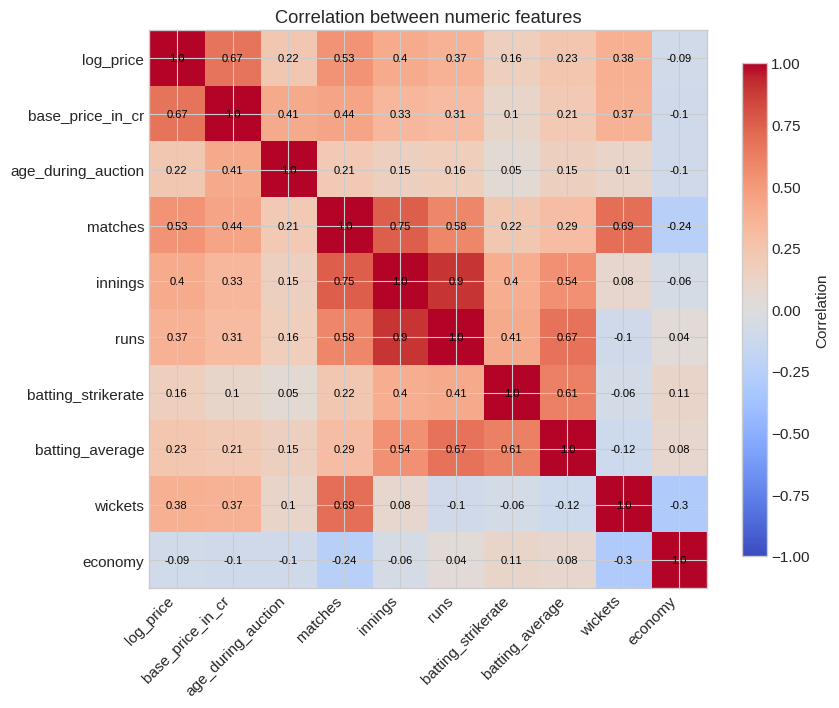

saved figure: correlation_heatmap_of_numeric_feature.png


'from base price is having the highest correlation between log-price and base price followed by the number of matches played by any players works a lot ,'

In [ ]:

corr_cols = ["log_price", "base_price_in_cr", "age_during_auction", "matches", "innings",
             "runs", "batting_strikerate", "batting_average", "wickets", "economy"]
corr = priced[corr_cols].corr()

figure, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, round(corr.values[i, j], 2),
                ha="center", va="center", color="black", fontsize=8)
figure.colorbar(im, ax=ax, shrink=0.8, label="Correlation")
ax.set_title("Correlation between numeric features")
save(figure, "correlation_heatmap_of_numeric_feature.png")



4
2
2


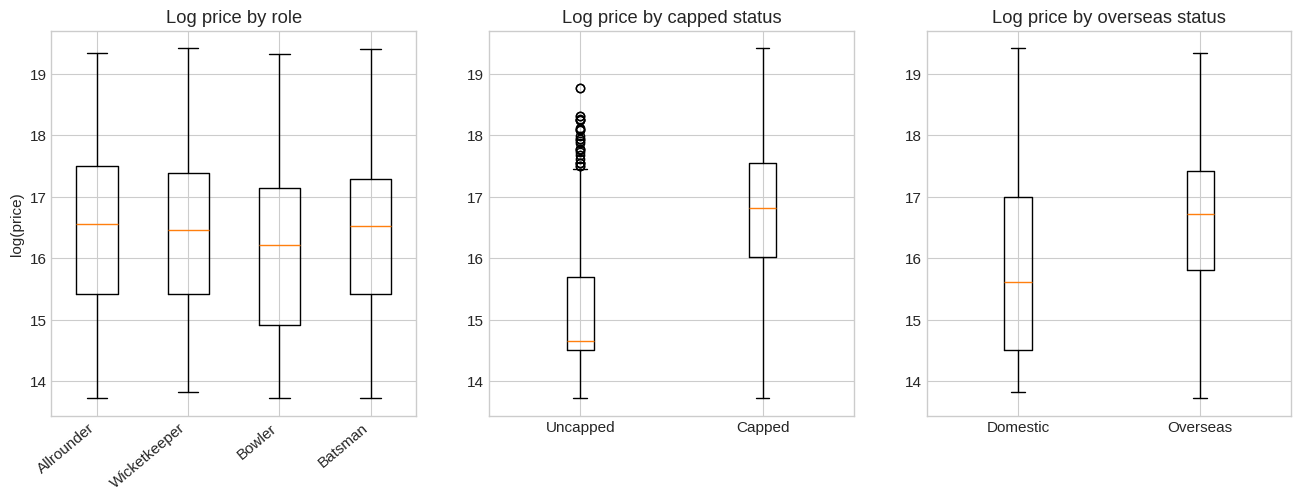

saved figure: log_price_by_role_capstatus_overseas.png


In [ ]:

figure, axes = plt.subplots(1, 3, figsize=(16, 5))


roles = list(priced["mapped_playing_role"].dropna().unique())
role_data = []
for r in roles:
    role_data.append(priced.loc[priced["mapped_playing_role"] == r, "log_price"].dropna().values)
print(len(role_data))
axes[0].boxplot(role_data)
axes[0].set_xticks(range(1, len(roles) + 1))
axes[0].set_xticklabels(roles, rotation=40, ha="right")
axes[0].set_title("Log price by role")
axes[0].set_ylabel("log(price)")


capped_data = []
capped_labels = ["Uncapped", "Capped"]
for v in [False, True]:
    capped_data.append(priced.loc[priced["is_capped"] == v, "log_price"].dropna().values)
print(len(capped_data))
axes[1].boxplot(capped_data)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(capped_labels)
axes[1].set_title("Log price by capped status")


overseas_data = []
overseas_labels = ["Domestic", "Overseas"]
for v in [0.0, 1.0]:
    overseas_data.append(priced.loc[priced["new_overseas"] == v, "log_price"].dropna().values)
print(len(overseas_data))

axes[2].boxplot(overseas_data)
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(overseas_labels)
axes[2].set_title("Log price by overseas status")
save(figure, "log_price_by_role_capstatus_overseas.png")

In [ ]:
import numpy as np
from scipy import stats

new_df = priced.copy()
print(new_df.shape)
categorical_features = ["mapped_playing_role", "year", "is_capped", "new_overseas", "is_mega_auction","has_prior_season"]
for category in categorical_features:
   new_df.dropna(subset=[category,'log_price'])
   groups = []
   for role,value in new_df.groupby(category):
    groups.append(value['log_price'].values)

   f_statistic, p_value = stats.f_oneway(*groups)

   total_mean = new_df['log_price'].mean()
   total_sum_of_squares = ((new_df['log_price'] - total_mean) ** 2).sum()
   sum_of_squares_between_groups = 0
   for g in groups:
    sum_of_squares_between_groups+= (np.mean(g) - total_mean) ** 2 * len(g)
   eta2 = sum_of_squares_between_groups / total_sum_of_squares

   print(category, "| F =", round(f_statistic, 2), "| p =", format(p_value, ".1e"), "| eta^2 =", round(eta2, 4))

(1644, 71)
mapped_playing_role | F = 3.58 | p = 1.3e-02 | eta^2 = 0.0201
year | F = 6.75 | p = 1.1e-16 | eta^2 = 0.0696
is_capped | F = 906.97 | p = 5.2e-159 | eta^2 = 0.3558
new_overseas | F = 124.45 | p = 6.8e-28 | eta^2 = 0.0694
is_mega_auction | F = 43.22 | p = 6.6e-11 | eta^2 = 0.0256
has_prior_season | F = 328.05 | p = 5.5e-67 | eta^2 = 0.1665


In [ ]:

stat_cols = ["matches","runs", "wickets", "batting_strikerate","economy"]
rows = []
for flag, group in df.groupby("has_prior_season"):
    pct = group[stat_cols].isna().mean() * 100
    pct.name = "has_prior_season=" + str(flag)
    rows.append(pct)
missing_by_prior = pd.DataFrame(rows)
missing_by_prior.to_csv(os.path.join(OUTPUT_DIR, "missingness_by_prior_season.csv"))
print("\nPercent missing in stat columns, split by has_prior_season:")
print(missing_by_prior.round(1))


Percent missing in stat columns, split by has_prior_season:
                        matches   runs  wickets  batting_strikerate  economy
has_prior_season=False    100.0  100.0    100.0               100.0    100.0
has_prior_season=True       0.0   11.2     33.9                12.0     33.9


In [ ]:

n_missing_id = df["player_id"].isna().sum()
missing_auction_result = df['auction_result'].isnull().sum()



issues = pd.DataFrame({
    "issue": [
        "rows with missing player_id",
        "Number of Players whose auction_result data is not there"
    ],
    "count": [n_missing_id, missing_auction_result],
})
issues.to_csv(os.path.join(OUTPUT_DIR, "06_integrity_issues.csv"), index=False)
print("\nKnown integrity issues:")
print(issues.to_string(index=False))

print("\nDONE. All tables and figures are in:", OUTPUT_DIR)


Known integrity issues:
                                                   issue  count
                             rows with missing player_id     17
Number of Players whose auction_result data is not there     32

DONE. All tables and figures are in: /content/images


In [ ]:
null_counts = df.isna().sum()
null_percent = (df.isna().mean() * 100).round(1)
null_table = pd.DataFrame({"null_count": null_counts, "null_percent": null_percent})
null_table = null_table.sort_values("null_count", ascending=False)
null_table.to_csv(os.path.join(OUTPUT_DIR, "A1_null_values.csv"))
print("\nA1. Nulls per column (top 15):")
print(null_table.head(15))


A1. Nulls per column (top 15):
                   null_count  null_percent
base_price_in_usd        3817          94.8
bbm_runs                 2951          73.3
bbi_wkts                 2951          73.3
bbm_wkts                 2951          73.3
bbm                      2951          73.3
bbi_runs                 2951          73.3
bbi                      2951          73.3
bowl_strikerate          2951          73.3
bowl_ave                 2951          73.3
10w                      2753          68.3
balls                    2753          68.3
economy                  2753          68.3
wickets                  2753          68.3
4w                       2753          68.3
5w                       2753          68.3


In [ ]:

check = df[df["prior_season_year"].notna()].copy()
check["prior_season_num"] = pd.to_numeric(check["prior_season_year"], errors="coerce")
diff = check["year"] - check["prior_season_num"]
print("\nB1. value counts of (year - prior_season):")
print(diff.value_counts(dropna=False))
"""All of them are ones only, so prior_season is a redundant column. """


B1. value counts of (year - prior_season):
1    4028
Name: count, dtype: int64


'All of them are ones only, so prior_season is a redundant column. '

In [ ]:

tournament_present = df["tournament"].notna()
has_prior = df["has_prior_season"] == True
print("\nB2. tournament vs has_prior_season:")
print("   tournament non-null           :", tournament_present.sum())
print("   has_prior_season True         :", has_prior.sum())
print("   prior season is True but tournament is empty :", (has_prior & ~tournament_present).sum())
print("   tournament present but prior season is empty:", (tournament_present & ~has_prior).sum())
print("   -> tournament is just prior_season as a label, so also redundant.")

"From here I make a decision that tournament is just a redundant"


B2. tournament vs has_prior_season:
   tournament non-null           : 1930
   has_prior_season True         : 1930
   prior season is True but tournament is empty : 0
   tournament present but prior season is empty: 0
   -> tournament is just prior_season as a label, so also redundant.


'From here I make a decision that tournament is just a redundant'

In [ ]:

drop_now = ["bbi", "bbm", "prior_season", "tournament", "player_name_stats"]

In [ ]:
playing_role_map = {
    "Bowling Allrounder": "Allrounder",
    "Batting Allrounder": "Allrounder",
    "Allrounder": "Allrounder",
    "Bowler": "Bowler",
    "Top order Batter": "Batsman",
    "Middle order Batter": "Batsman",
    "Opening Batter": "Batsman",
    "Batter": "Batsman",
    "Wicketkeeper Batter": "Wicketkeeper",
    "Wicketkeeper": "Wicketkeeper"
}
data["mapped_playing_role"] = data['player_role'].map(playing_role_map)
print("\n mapped_playing_role counts:")
print(data["mapped_playing_role"].value_counts(dropna=False))


 mapped_playing_role counts:
mapped_playing_role
Bowler          1306
Allrounder       899
Batsman          783
NaN              667
Wicketkeeper     373
Name: count, dtype: int64


In [ ]:
batsman_df = data[data["mapped_playing_role"] == "Batsman"].copy()
bowler_df = data[data["mapped_playing_role"] == "Bowler"].copy()
allrounder_df = data[data["mapped_playing_role"] == "Allrounder"].copy()
wicketkeeper_df = data[data["mapped_playing_role"] == "Wicketkeeper"].copy()

batsman_df.to_csv(os.path.join(OUTPUT_DIR, "batsman.csv"), index=False)
bowler_df.to_csv(os.path.join(OUTPUT_DIR, "bowler.csv"), index=False)
allrounder_df.to_csv(os.path.join(OUTPUT_DIR, "allrounder.csv"), index=False)
wicketkeeper_df.to_csv(os.path.join(OUTPUT_DIR, "wicketkeeper.csv"), index=False)

print("    batsman   :", len(batsman_df))
print("    bowler    :", len(bowler_df))
print("    allrounder:", len(allrounder_df))
print("    wicketkeeper:", len(wicketkeeper_df))

for name, sub in [("batsman", batsman_df), ("bowler", bowler_df), ("allrounder", allrounder_df),("wicketkeeper",wicketkeeper_df)]:
    n_priced = ((sub["auction_result"] == "sold") &
                (sub["sold_price"].notna()) & (sub["sold_price"] > 0)).sum()
    print("    ", name, "sold-with-price rows:", n_priced)

    batsman   : 783
    bowler    : 1306
    allrounder: 899
    wicketkeeper: 373
     batsman sold-with-price rows: 316
     bowler sold-with-price rows: 592
     allrounder sold-with-price rows: 416
     wicketkeeper sold-with-price rows: 147
